In [14]:
import os
print("Contents of /content/project4/:")
print(os.listdir('/content/project4/'))

Contents of /content/project4/:
['object_detection_path', 'README.md', 'ocr_path', 'sample_images', 'outputs']


In [20]:
import os
print("Contents of /content/project4/object_detection_path/:")
print(os.listdir('/content/project4/object_detection_path/'))
print("\nContents of /content/project4/sample_images/:")
print(os.listdir('/content/project4/sample_images/'))

Contents of /content/project4/object_detection_path/:
['MobileNetSSD_deploy.caffemodel', 'MobileNetSSD_deploy.prototxt', 'object_detection.py']

Contents of /content/project4/sample_images/:
['person_sample.jpg', 'cat_sample.jpg', 'document_sample.png']


### Upload Your Image for Object Detection

Use the cell below to upload an image file from your local machine. Once uploaded, I will use this image for object detection.

### Execute Object Detection Script
Now, let's run the object detection script. I'll read the original script, update the hardcoded model paths to point to their correct location within the extracted `project4` directory, save this modified script temporarily, and then execute it with a sample image. Finally, I'll display the image with the detected objects.

In [28]:
from google.colab import files
import shutil

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    # Move the uploaded file to a known location, or directly use its path
    # For simplicity, let's assume we'll use the first uploaded file.
    uploaded_image_path = f'/content/{filename}'
    print(f'Uploaded image saved to: {uploaded_image_path}')

if 'uploaded_image_path' in locals():
    # Now, modify the object detection cell to use this new path
    # I'll update the 'sample_image_path' variable and re-run the detection.
    print("You have successfully uploaded an image. Please run the next cell to perform object detection on it.")
else:
    print("No file was uploaded.")

Saving ocr_output.png to ocr_output (2).png
User uploaded file "ocr_output (2).png"
Uploaded image saved to: /content/ocr_output (2).png
You have successfully uploaded an image. Please run the next cell to perform object detection on it.


Using image for detection: /content/ocr_output (2).png
Output will be saved to: /content/ocr_output (2)_detected.png
Original script copied to /content/modified_object_detection_temp.py
Executing command: python /content/modified_object_detection_temp.py --prototxt /content/project4/object_detection_path/MobileNetSSD_deploy.prototxt --model /content/project4/object_detection_path/MobileNetSSD_deploy.caffemodel /content/ocr_output (2).png --out /content/ocr_output (2)_detected.png
Script Output: [1/4] Loaded image: /content/ocr_output (2).png  shape=(532, 918, 3)
[1/4] MobileNet-SSD (Caffe, pre-trained on PASCAL VOC) loaded via cv2.dnn
[2/4] Built 4D blob: shape=(1, 3, 300, 300) (mean-subtracted, resized to 300x300)
[3/4] Forward pass complete: 100 raw candidate detections
[3/4] Confidence gate (>= 80%): 0 accepted
[4/4] Saved annotated output -> /content/ocr_output (2)_detected.png

ACCEPTED DETECTIONS (confidence >= 80%)
  (no detections met the confidence threshold)
-----------------

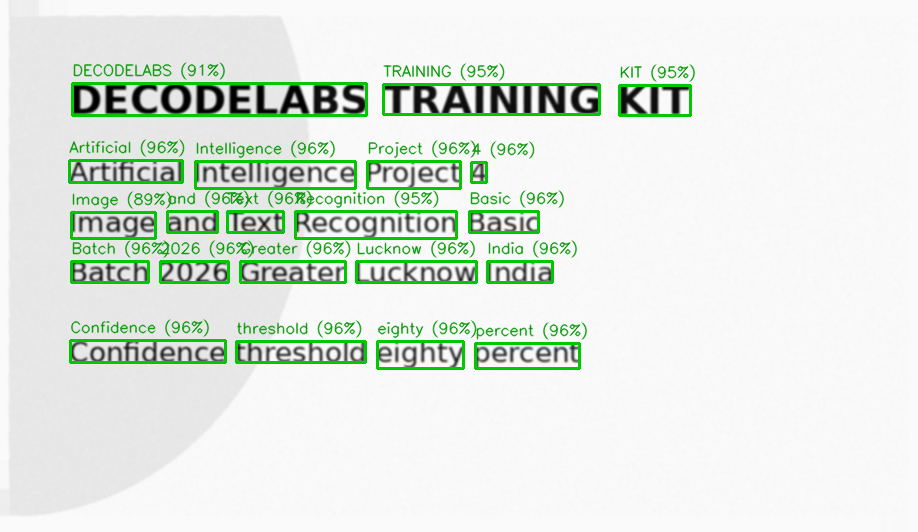

In [29]:
import os
import subprocess
from IPython.display import Image, display

# Define paths
original_script_path = '/content/project4/object_detection_path/object_detection.py'

prototxt_correct_path = '/content/project4/object_detection_path/MobileNetSSD_deploy.prototxt'
caffemodel_correct_path = '/content/project4/object_detection_path/MobileNetSSD_deploy.caffemodel'

# Use the dynamically uploaded image path
# The 'uploaded_image_path' variable should be available from the previous cell's execution
if 'uploaded_image_path' in locals():
    current_image_path = uploaded_image_path
    output_image_name = os.path.basename(current_image_path).replace('.', '_detected.')
    output_image_path = f'/content/{output_image_name}'
else:
    print("No uploaded image detected, defaulting to sample image.")
    current_image_path = '/content/project4/sample_images/person_sample.jpg'
    output_image_path = '/content/detected_person_sample.jpg'

print(f"Using image for detection: {current_image_path}")
print(f"Output will be saved to: {output_image_path}")

# Read the content of the original script (no path replacement needed now)
if not os.path.exists(original_script_path):
    print(f"Error: Script not found at {original_script_path}")
else:
    with open(original_script_path, 'r') as f:
        script_content = f.read()

    # Write the content to a temporary file for execution (without path replacements)
    # The paths will be passed as command-line arguments.
    modified_script_temp_path = '/content/modified_object_detection_temp.py'
    with open(modified_script_temp_path, 'w') as f:
        f.write(script_content)

    print(f"Original script copied to {modified_script_temp_path}")

    # Execute the modified script with correct arguments
    try:
        command = [
            'python',
            modified_script_temp_path,
            '--prototxt',
            prototxt_correct_path,
            '--model',
            caffemodel_correct_path,
            current_image_path, # Positional argument for image
            '--out',
            output_image_path
        ]
        print(f"Executing command: {' '.join(command)}")
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        print("Script Output:", result.stdout)
        if result.stderr:
            print("Script Error Output:", result.stderr)

        # Display the output image
        if os.path.exists(output_image_path):
            print(f"Displaying output image from {output_image_path}:")
            display(Image(output_image_path))
        else:
            print(f"Error: Output image not found at {output_image_path}")

    except subprocess.CalledProcessError as e:
        print(f"Error executing script: {e}")
        print("Stdout:", e.stdout)
        print("Stderr:", e.stderr)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")